# Phase 1 - Extraction et Prétraitement (Approche Memory-Safe)

-> Lecture et isolation de chaque frame pour pouvoir les traiter indépendamment

-> Stocker uniquement les images (proxys) en RAM, pas les images hautes résolutions (piège Out-of-Memory pour les longues vidéos)

-> Redimensionnement proportionnel (préservation du ratio)

-> Extraire le FPS d'origine (piège du destruction du rythme de la vidéo filmée)


--- MÉTADONNÉES EXTRAITES ---
Dimensions : 1920x1080 pixels
Framerate  : 25.0 FPS

--- PRÉTRAITEMENT ---
Taille des proxys en RAM : 128x72 pixels (Niveaux de gris)



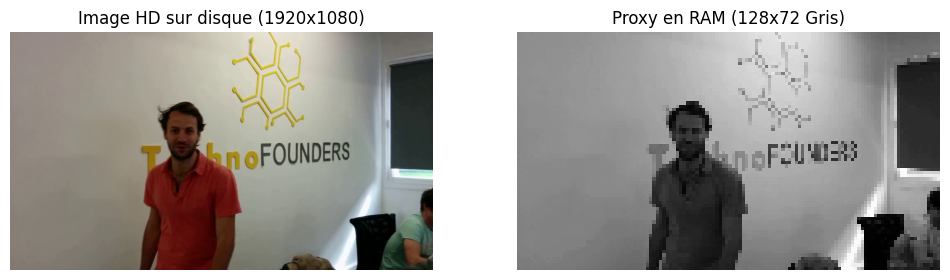

In [5]:
import cv2
import tempfile
import os
import matplotlib.pyplot as plt

input_video = "corrupted_video.mp4"

# Extraction des métadonnées
cap = cv2.VideoCapture(input_video)
if not cap.isOpened():
    print(f"Erreur : Impossible d'ouvrir la vidéo {input_video}")

fps_original = cap.get(cv2.CAP_PROP_FPS)
width_original = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height_original = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"--- MÉTADONNÉES EXTRAITES ---")
print(f"Dimensions : {width_original}x{height_original} pixels")
print(f"Framerate  : {fps_original} FPS\n")

# Simulation de l'extraction (Memory-Safe)
temp_dir = tempfile.TemporaryDirectory()
proxies_gray = {} # On stocke directement en gris
frame_paths = {}

# Calcul proportionnel du proxy pour garder les mêmes ratios
proxy_w = 128
proxy_h = int((proxy_w / width_original) * height_original)

print(f"--- PRÉTRAITEMENT ---")
print(f"Taille des proxys en RAM : {proxy_w}x{proxy_h} pixels (Niveaux de gris)\n")

frame_id = 0
while True: 
    ret, frame = cap.read()
    if not ret:
        break
        
    # Sauvegarde HD sur disque (Lourd)
    frame_path = os.path.join(temp_dir.name, f"frame_{frame_id:04d}.jpg")
    cv2.imwrite(frame_path, frame)
    frame_paths[frame_id] = frame_path
    
    # Création du proxy PROPORTIONNEL en niveaux de gris (Standardisation parfaite pour SSIM)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    proxy = cv2.resize(gray, (proxy_w, proxy_h))
    proxies_gray[frame_id] = proxy
    
    frame_id += 1

cap.release()

original_frame_bgr = cv2.imread(frame_paths[0])
original_frame_rgb = cv2.cvtColor(original_frame_bgr, cv2.COLOR_BGR2RGB)
proxy_visuel = proxies_gray[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(original_frame_rgb)
axes[0].set_title(f"Image HD sur disque ({width_original}x{height_original})")
axes[0].axis('off')

# Affichage en niveaux de gris (cmap='gray') avec les dimensions dynamiques
axes[1].imshow(proxy_visuel, cmap='gray')
axes[1].set_title(f"Proxy en RAM ({proxy_w}x{proxy_h} Gris)")
axes[1].axis('off')

plt.show()

# Phase 2 - Matrice de Distance et Réordonnancement Global (Pathfinding)

-> Objectif : Retrouver l'ordre chronologique de la vidéo en maximisant la continuité visuelle entre chaque image consécutive

-> Choix de la métrique (SSIM (Structural Similarity Index)) : Il compare les structures (bords, contrastes) et se rapproche de la perception humaine. Renvoie un score de similarité (1 = identique), nous le convertissons donc en distance mathématique : Distance = 1 - SSIM

-> Dilemme Temporel (Vidéo inversée) : La distance entre l'image A et B est la même qu'entre B et A (matrice symétrique). L'algorithme garantit la continuité structurelle, le sens de lecture est un problème secondaire pour ce test.

-> Algorithme Glouton (Greedy NN) consiste à prendre une image de départ au hasard et de relier la plus proche. Si l'algorithme commence par l'image du milieu de la vidéo, il reconstruira la moitié, puis fera un "saut visuel" gigantesque.

    -> Solution : Puisque le jeu de données est raisonnable (~120 frames), on lance l'algorithme Glouton en utilisant chaque image tour à tour comme point de départ. On ne conserve à la fin que le chemin dont le coût total est le plus faible.

--- INITIALISATION DU PATHFINDING ---
Calcul de la matrice de distance (114x114) en cours...
Matrice calculée en 2.35 secondes.

Recherche du chemin optimal (Multi-départs)...
--- RÉSULTAT ---
Chemin optimal trouvé avec un coût total de : 25.2682
Aperçu du début du chemin : [76, 101, 83, 36, 88, 42, 69, 10, 78, 96] ...


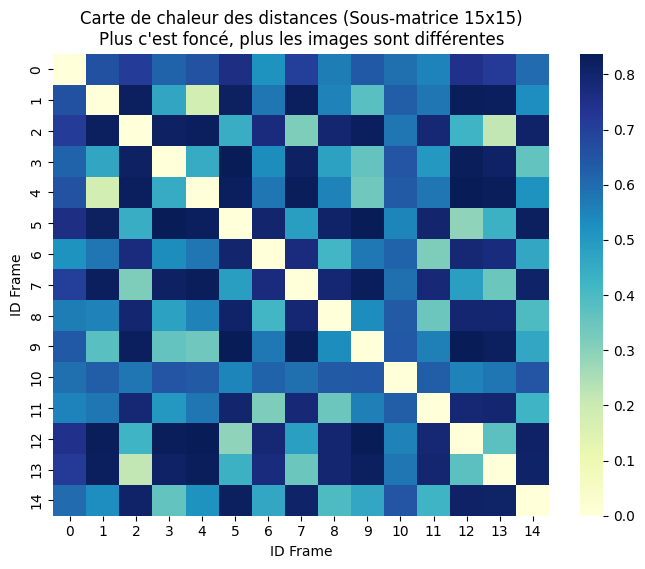

In [6]:
import numpy as np
from skimage.metrics import structural_similarity as ssim
import seaborn as sns
import time

# proxies est la liste/dictionnaire de nos proxys en niveaux de gris générés dans la Phase 1.
n_frames = len(proxies_gray) 

print(f"--- INITIALISATION DU PATHFINDING ---")
print(f"Calcul de la matrice de distance ({n_frames}x{n_frames}) en cours...")

dist_matrix = np.zeros((n_frames, n_frames))

start_time = time.time()

# Calcul de la matrice de distance symétrique (1 - SSIM)
for i in range(n_frames):
    for j in range(i + 1, n_frames):
        score = ssim(proxies_gray[i], proxies_gray[j], data_range=255)
        dist = 1.0 - score
        dist_matrix[i, j] = dist
        dist_matrix[j, i] = dist # Symétrie

print(f"Matrice calculée en {time.time() - start_time:.2f} secondes.\n")

# Algorithme Glouton (Greedy NN) Multi-départs
print("Recherche du chemin optimal (Multi-départs)...")
best_path = []
best_cost = float('inf')

for start_idx in range(n_frames):
    unvisited = set(range(n_frames))
    current = start_idx
    unvisited.remove(current)
    
    path = [current]
    cost = 0.0
    
    while unvisited:
        # Trouve le voisin le plus proche non visité
        nearest = min(unvisited, key=lambda x: dist_matrix[current, x])
        cost += dist_matrix[current, nearest]
        
        current = nearest
        unvisited.remove(current)
        path.append(current)
        
    # Met à jour le meilleur chemin global
    if cost < best_cost:
        best_cost = cost
        best_path = path

print(f"--- RÉSULTAT ---")
print(f"Chemin optimal trouvé avec un coût total de : {best_cost:.4f}")
print(f"Aperçu du début du chemin : {best_path[:10]} ...")

# Preuve visuelle : Heatmap d'un sous-ensemble de la matrice (ex: 15x15)
# Cela permet de montrer que la diagonale est bien à 0 (distance d'une image avec elle-même)
subset_size = min(15, n_frames)
sub_matrix = dist_matrix[:subset_size, :subset_size]

plt.figure(figsize=(8, 6))
sns.heatmap(sub_matrix, cmap="YlGnBu", annot=False)
plt.title(f"Carte de chaleur des distances (Sous-matrice {subset_size}x{subset_size})\nPlus c'est foncé, plus les images sont différentes")
plt.xlabel("ID Frame")
plt.ylabel("ID Frame")
plt.show()

# Phase 3 - Élimination des Intrus (Filtrage par Masse et Continuité)

 -> Objectif : Repérer où se cachent les parasites (qui ont été naturellement repoussés aux extrémités ou isolés)

-> Seuil Dynamique Robuste. Nous utilisons la médiane et la MAD (Median Absolute Deviation). Contrairement à la moyenne classique, la médiane n'est pas faussée par les valeurs extrêmes (les parasites). Notre seuil de coupure s'adapte donc dynamiquement à la "normalité" de chaque vidéo. (Piège des seuils arbitraires)

--- DÉTECTION DES RUPTURES (SHOT BOUNDARY) ---
Médiane des distances : 0.1644
Seuil de coupure dynamique : 0.4000

--- RÉSULTAT DU FILTRAGE ---
Nombre de blocs détectés : 13
Frames conservées (Vidéo principale) : 100 / 114
Frames rejetées (Parasites) : 14



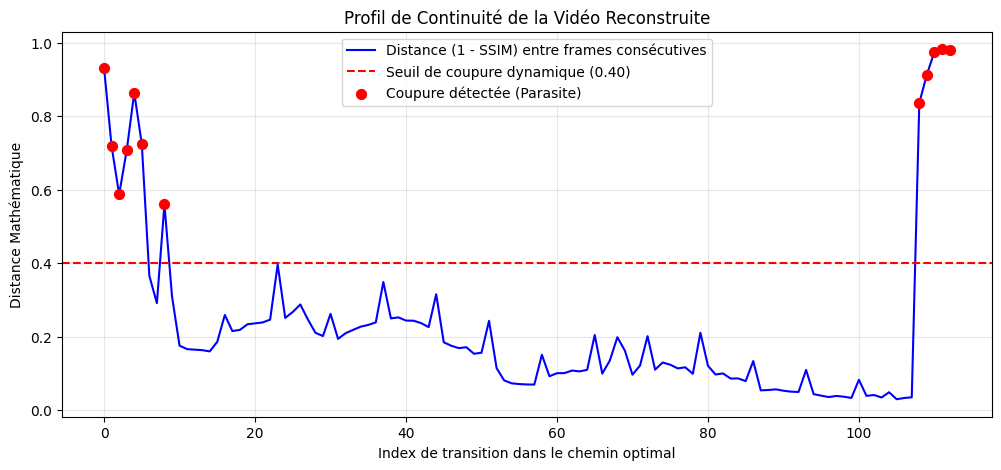

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# On récupère les coûts de transition entre chaque image consécutive de notre chemin.
transitions = []
for i in range(len(best_path) - 1):
    id_a = best_path[i]
    id_b = best_path[i+1]
    transitions.append(dist_matrix[id_a, id_b])

transitions = np.array(transitions)

print(f"--- DÉTECTION DES RUPTURES (SHOT BOUNDARY) ---")

# Calcul du seuil dynamique (Approche Stricte)
median = np.median(transitions)
mad = np.median(np.abs(transitions - median))

# On utilise la formule validée dans le script (3 * mad)
threshold = median + (3 * mad)

print(f"Médiane des distances : {median:.4f}")
print(f"Seuil de coupure dynamique : {threshold:.4f}\n")

# Découpage aux pics extrêmes
sub_sequences = []
current_seq = [best_path[0]]

for i, cost in enumerate(transitions):
    if cost > threshold:
        # Coupure détectée
        sub_sequences.append(current_seq)
        current_seq = [best_path[i+1]]
    else:
        current_seq.append(best_path[i+1])
sub_sequences.append(current_seq)

# Filtrage Strict (On ne conserve QUE la plus grande séquence)
final_sequence = max(sub_sequences, key=len)

print(f"--- RÉSULTAT DU FILTRAGE ---")
print(f"Nombre de blocs détectés : {len(sub_sequences)}")
print(f"Frames conservées (Vidéo principale) : {len(final_sequence)} / {n_frames}")
print(f"Frames rejetées (Parasites) : {n_frames - len(final_sequence)}\n")

# Preuve visuelle : Le graphique des distances
plt.figure(figsize=(12, 5))
plt.plot(transitions, label="Distance (1 - SSIM) entre frames consécutives", color="blue", linewidth=1.5)
plt.axhline(y=threshold, color="red", linestyle="--", label=f"Seuil de coupure dynamique ({threshold:.2f})")

# Mise en évidence visuelle des pics
outliers = np.where(transitions > threshold)[0]
plt.scatter(outliers, transitions[outliers], color="red", s=50, zorder=5, label="Coupure détectée (Parasite)")

plt.title("Profil de Continuité de la Vidéo Reconstruite")
plt.xlabel("Index de transition dans le chemin optimal")
plt.ylabel("Distance Mathématique")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Phase 4 - Reconstruction de la Vidéo (Streaming Memory-Safe)

-> Nous utilisons les ID de notre séquence finale pour aller lire les images HD une par une directement sur le disque dur (piège du crash de la RAM à la dernière seconde). La consommation mémoire de cette étape est quasi nulle, peu importe la durée de la vidéo.

-> On initialise le VideoWriter avec les variables width_original et height_original extraites dynamiquement lors de la Phase 1.

-> On réinjecte la variable fps_original (extraite en Phase 1) pour garantir un playback 100% fidèle à la source.

In [8]:
print(f"--- DÉMARRAGE DE LA RECONSTRUCTION ---")
output_video = "restored_video_final.mp4"

final_sequence.reverse() # Inversion de la séquence (Correction du 50/50) potentielle à activer si la vidéo est à l'envers

# Initialisation de l'encodeur vidéo
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video, fourcc, fps_original, (width_original, height_original))

print(f"Écriture dans : {output_video}")
print(f"Paramètres attendus : {width_original}x{height_original} à {fps_original} FPS")

# Memory-safe
frames_written = 0
for frame_id in final_sequence:
    image_path = frame_paths[frame_id]
    
    # Lecture de l'image HD
    frame_hd = cv2.imread(image_path)
    
    # SÉCURITÉ : On vérifie que l'image existe vraiment et a la bonne taille
    if frame_hd is None:
        print(f"Impossible de lire l'image {image_path}")
        break
        
    h, w = frame_hd.shape[:2]
    if h != height_original or w != width_original:
        print(f"Frame {frame_id} fait {w}x{h} au lieu de {width_original}x{height_original}")
        break
    
    # Écriture dans la vidéo
    out.write(frame_hd)
    frames_written += 1

# Libération du flux vidéo
out.release()
print(f"Vidéo restaurée ! ({frames_written} frames écrites)")

# Nettoyage final
print("Nettoyage des fichiers temporaires HD sur le disque...")
try:
    temp_dir.cleanup()
    print("Dossier temporaire supprimé.")
except Exception as e:
    print("Le dossier temporaire a déjà été nettoyé ou n'existe plus.")

--- DÉMARRAGE DE LA RECONSTRUCTION ---
Écriture dans : restored_video_final.mp4
Paramètres attendus : 1920x1080 à 25.0 FPS
Vidéo restaurée ! (100 frames écrites)
Nettoyage des fichiers temporaires HD sur le disque...
Dossier temporaire supprimé.
